### classifier, torch

In [1]:
%pip install --quiet torch datasets nltk tqdm matplotlib kagglehub ipywidgets numpy pandas

import numpy as np
import torch
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /Users/ant.korneev/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [3]:
with open(path + '/IMDB Dataset.csv', "r") as file:
    content = file.read()

In [4]:
df = pd.read_csv(path + '/IMDB Dataset.csv', sep=',', header=None)
ds = df.to_numpy()
ds = ds[1:]

len(ds)

50000

In [5]:
import nltk

tokenizer = nltk.tokenize.WordPunctTokenizer()

train = [tokenizer.tokenize(pair[0].lower()) for pair in ds[:25000]]
val = [tokenizer.tokenize(pair[0].lower()) for pair in ds[25000:]]

In [30]:
# [negative prob, positive prob]
train_labels = [[1, 0] if pair[1] == 'negative' else [0, 1] for pair in ds[:25000]]
val_labels = [[1, 0] if pair[1] == 'negative' else [0, 1] for pair in ds[25000:]]

In [7]:
PAD_TOKEN = '<pad>'

train_seq_len = 0
for t in train:
    if len(t) > train_seq_len:
        train_seq_len = len(t)

train = [text + [PAD_TOKEN] * (train_seq_len - len(text)) for text in train]

val_seq_len = 0
for t in val:
    if len(t) > val_seq_len:
        val_seq_len = len(t)

val = [text + [PAD_TOKEN] * (val_seq_len - len(text)) for text in val]

In [8]:
vocab_set = set()
for t in train:
    for w in t:
        vocab_set.add(w)
        
for t in val:
    for w in t:
        vocab_set.add(w)

In [9]:
vocab_i_map = {}
i_vocab_map = {}
for i, token in enumerate(vocab_set):
    vocab_i_map[token] = i
    i_vocab_map[i] = token

In [10]:
for i, text in enumerate(train):
    for j, token in enumerate(text):
        train[i][j] = vocab_i_map[token]
        
for i, text in enumerate(val):
    for j, token in enumerate(text):
        val[i][j] = vocab_i_map[token]

In [11]:
print(val[1])
[i_vocab_map[i] for i in val[1]]

[34402, 46850, 62272, 69583, 25656, 76352, 40530, 18143, 15080, 102054, 46470, 104288, 63456, 1773, 68365, 3124, 78467, 66362, 76352, 45654, 13, 69641, 69194, 1773, 39375, 95377, 68365, 46850, 35734, 62272, 68432, 35734, 98589, 62272, 27877, 50385, 35734, 74344, 69641, 36870, 46850, 62272, 34577, 30998, 99466, 43450, 1773, 79587, 66108, 54931, 57100, 54931, 81585, 84522, 20623, 62272, 9649, 42020, 27960, 46850, 72496, 18696, 46850, 2919, 49979, 57680, 46693, 10630, 52004, 95377, 78902, 39075, 85644, 69641, 15234, 35734, 1773, 45606, 473, 13889, 51840, 69641, 78902, 55684, 95377, 71150, 68897, 57680, 58979, 104146, 2919, 3124, 78902, 26723, 103776, 95377, 13889, 71969, 33870, 50701, 104032, 473, 51210, 46850, 76116, 13889, 68476, 37741, 46850, 69641, 13889, 13777, 71552, 37741, 46850, 81948, 55451, 99006, 32432, 42020, 84522, 18031, 24266, 80128, 13889, 71111, 14111, 93351, 59665, 66852, 47812, 42020, 78902, 53432, 473, 76352, 24107, 46850, 35734, 62272, 93543, 20623, 54647, 62272, 5798

['god',
 ',',
 'i',
 'never',
 'felt',
 'so',
 'insulted',
 'in',
 'my',
 'whole',
 'life',
 'than',
 'with',
 'this',
 'crap',
 '.',
 'there',
 'are',
 'so',
 'many',
 'ways',
 'to',
 'describe',
 'this',
 'piece',
 'of',
 'crap',
 ',',
 'that',
 'i',
 'think',
 'that',
 'if',
 'i',
 'said',
 'everything',
 'that',
 'came',
 'to',
 'mind',
 ',',
 'i',
 'would',
 'get',
 'banned',
 'by',
 'this',
 'site',
 '.<',
 'br',
 '/><',
 'br',
 '/>',
 'how',
 'do',
 'i',
 'begin',
 '?',
 'well',
 ',',
 'for',
 'one',
 ',',
 'it',
 'doesn',
 "'",
 't',
 'take',
 'knowledge',
 'of',
 'the',
 'original',
 'series',
 'to',
 'know',
 'that',
 'this',
 'movie',
 'is',
 'a',
 'slap',
 'to',
 'the',
 'face',
 'of',
 'people',
 'who',
 "'",
 've',
 'seen',
 'it',
 '.',
 'the',
 'biggest',
 'butchering',
 'of',
 'a',
 'theme',
 'song',
 'ever',
 'made',
 'is',
 'here',
 ',',
 'from',
 'a',
 'metal',
 'version',
 ',',
 'to',
 'a',
 'freaking',
 'rap',
 'version',
 ',',
 'what',
 'were',
 'they',
 'thinking

In [13]:
vocab_size = len(vocab_set)
emb_dim = 64
hid_size = 512

In [25]:
class Cls(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.embs = torch.nn.Embedding(vocab_size, emb_dim)
        
        self.lstm = torch.nn.LSTM(emb_dim, hid_size, 4)
        
        self.norm = torch.nn.LayerNorm(hid_size)
        self.dropout = torch.nn.Dropout(p=0.2)
        
        self.fc1 = torch.nn.Linear(hid_size, hid_size)
        self.activation1 = torch.nn.ReLU()
        
        self.fc2 = torch.nn.Linear(hid_size, 2)
        # self.activation2 = torch.nn.Sigmoid()
        
        
        
    # X: [batch_size, seq_len]
    def forward(self, X):
        X = self.embs(X) # [batch_size, seq_len, emb_dim]
        
        X, (hn, cn) = self.lstm(X)
        
        X = self.norm(X)
        X = self.dropout(X)
        
        X = self.fc1(X) # [batch_size, seq_len, hid_size]
        X = self.activation1(X)
        
        X = self.fc2(X) # [batch_size, seq_len, 2]
        # X = self.activation2(X)
    
        return X


In [26]:
dummy_batch = torch.tensor(train[:2])

In [27]:
model = Cls()

In [28]:
model.forward(dummy_batch)

tensor([[[ 0.0833, -0.1584],
         [ 0.0242, -0.1658],
         [ 0.1655, -0.2511],
         ...,
         [-0.1683, -0.1561],
         [-0.1747, -0.0345],
         [ 0.0748, -0.0278]],

        [[ 0.0408, -0.2614],
         [ 0.0867,  0.0646],
         [-0.0424, -0.0853],
         ...,
         [ 0.1228, -0.1292],
         [ 0.1571, -0.1352],
         [ 0.0848, -0.1260]]], grad_fn=<ViewBackward0>)

In [29]:
opt = torch.optim.Adam(model.parameters())

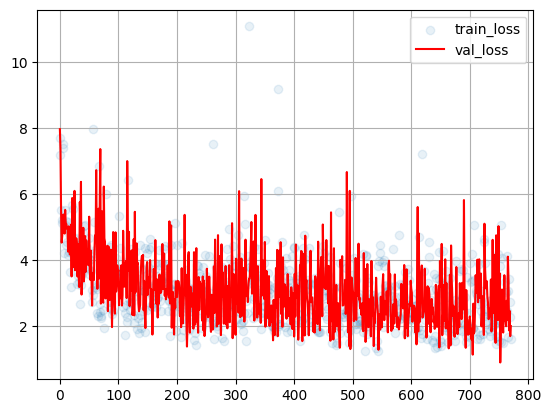

 49%|████▉     | 773/1562 [46:07<47:05,  3.58s/it]


KeyboardInterrupt: 

In [31]:
batch_size = 16

train_loss = []
val_loss = []

for i in tqdm(range(0, len(train), batch_size), total=len(train) // batch_size):
    if i + batch_size > len(train):
        break
    
    batch = train[i : i + batch_size]
    batch = torch.tensor(batch)
    val_batch = val[i : i + batch_size]
    val_batch = torch.tensor(val_batch)
    
    batch_labels = train_labels[i : i + batch_size]
    batch_labels = torch.tensor(batch_labels)
    val_batch_labels = val_labels[i : i + batch_size]
    val_batch_labels = torch.tensor(val_batch_labels)
    
    logits = model.forward(batch)
    logits = logits.squeeze(dim=2)
    val_logits = model.forward(val_batch)
    val_logits = val_logits.squeeze(dim=2)
    
    batch_train_loss = torch.nn.functional.cross_entropy(logits, batch_labels)
    train_loss.append(batch_train_loss.detach().numpy())
    batch_val_loss = torch.nn.functional.cross_entropy(val_logits, val_batch_labels)
    val_loss.append(batch_val_loss.detach().numpy())
    
    batch_train_loss.backward()
    opt.step()
    opt.zero_grad()
    
    if i % 10 == 0:
        clear_output(True)
        plt.scatter(range(len(train_loss)), train_loss, alpha=0.1, label='train_loss')
        if len(val_loss):
            plt.plot(range(len(val_loss)), val_loss, color='red', label='val_loss')
        plt.legend(); plt.grid(); plt.show()
    

In [33]:
bad = ['awful! a waste of time!', 'this movie is so bad it is of its own kind', 'complete utter garbage!']
good = ['what a nice movie!', 'what a day to have eyes! absolutely astonishing!', 'solid 10! I am speechless']

In [38]:
all = bad + good

for i, review in enumerate(all):
    tokenized = tokenizer.tokenize(review.lower())
    all[i] = [vocab_i_map[token] for token in tokenized]
    

In [45]:
for review in all:
    logits = model.forward(torch.tensor(review))
    print(torch.nn.functional.softmax(logits.sum(dim=-2), dim=-1))

tensor([0.0736, 0.9264], grad_fn=<SoftmaxBackward0>)
tensor([0.0374, 0.9626], grad_fn=<SoftmaxBackward0>)
tensor([0.1902, 0.8098], grad_fn=<SoftmaxBackward0>)
tensor([0.1319, 0.8681], grad_fn=<SoftmaxBackward0>)
tensor([0.0309, 0.9691], grad_fn=<SoftmaxBackward0>)
tensor([0.0840, 0.9160], grad_fn=<SoftmaxBackward0>)


In [52]:
# TOOD: сопоставляет токену класс, а должен - последовательности